<a href="https://www.kaggle.com/code/subhadiphensh/fashion-mnist-fnn-model?scriptVersionId=286507139" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install "protobuf<4" --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import platform
import math

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.datasets import fashion_mnist
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

2025-12-16 06:54:36.616304: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765868076.782892      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765868076.831211      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print(f"Python Version : {platform.python_version()}")
print(f'Tensorflow Version : {tf.__version__}')
print(f"Keras Version : {tf.keras.__version__}")

Python Version : 3.11.13
Tensorflow Version : 2.18.0
Keras Version : 3.8.0


In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (60000, 28, 28)
y_train : (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


In [6]:
(_, IMAGE_WIDTH, IMAGE_HEIGHT) = X_train.shape
IMAGE_CHANNELS = 1

print(f"IMAGE_WIDTH : {IMAGE_WIDTH}")
print(f"IMAGE_HEIGHT : {IMAGE_HEIGHT}")
print(f"IMAGE_CHANNELS : {IMAGE_CHANNELS}")

IMAGE_WIDTH : 28
IMAGE_HEIGHT : 28
IMAGE_CHANNELS : 1


In [7]:
pd.set_option("display.max_columns", None)

In [8]:
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13,73,0,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,3,0,36,136,127,62,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,0,0,6,0,102,204,176,134,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,236,207,178,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,0,1,0,69,207,223,218,216,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,1,1,0,200,232,232,233,229,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,183,225,216,223,228,235,227,224,222,224,221,223,245,173,0


In [9]:
pd.DataFrame(X_test[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,0,0,7,0,37,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,27,84,11,0,0,0,0,0,0,119,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,88,143,110,0,0,0,0,22,93,106,0,0


In [10]:
plt.style.use('dark_background')

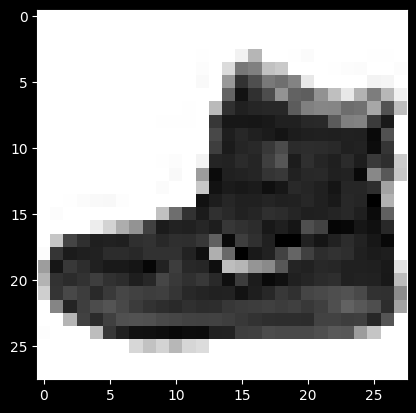

In [11]:
plt.imshow(X_train[0], cmap = plt.cm.binary)
plt.show()

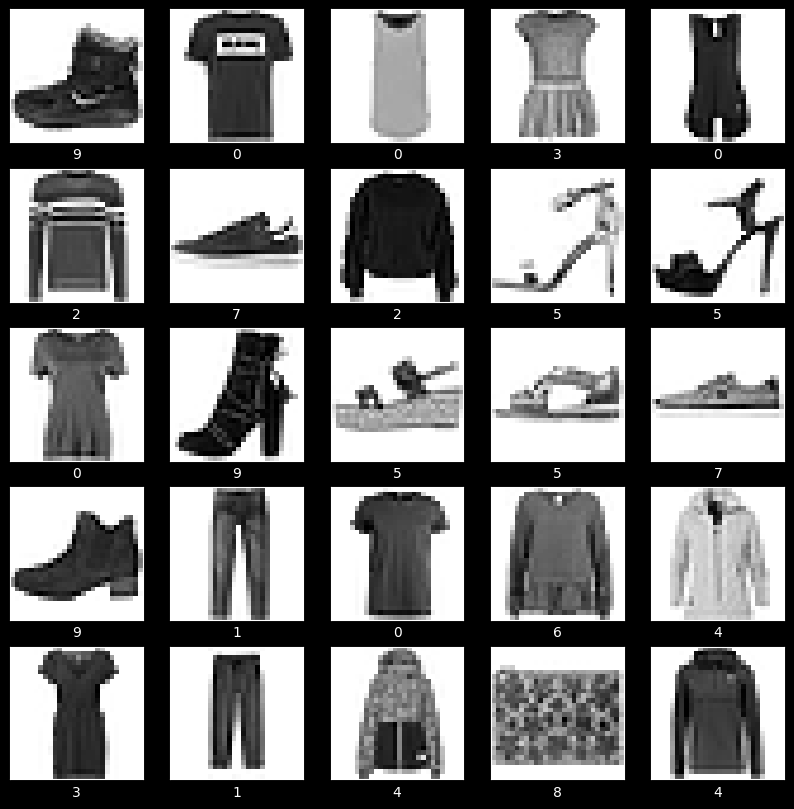

In [12]:
numbers_to_display = 25

num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize = (10,10))

for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap = plt.cm.binary)
    plt.xlabel(y_train[i])

plt.show()

In [13]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

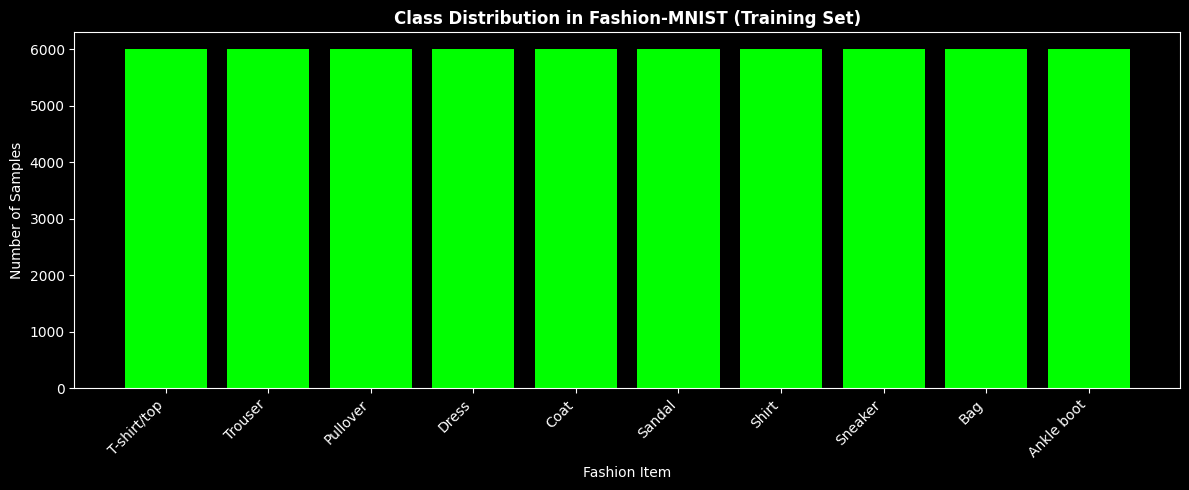

In [14]:
unique, counts = np.unique(y_train, return_counts = True)

plt.figure(figsize = (12, 5))
plt.bar(class_names, counts, color = 'Lime')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Fashion Item")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Fashion-MNIST (Training Set)", fontweight = "semibold")
plt.tight_layout()
plt.show()

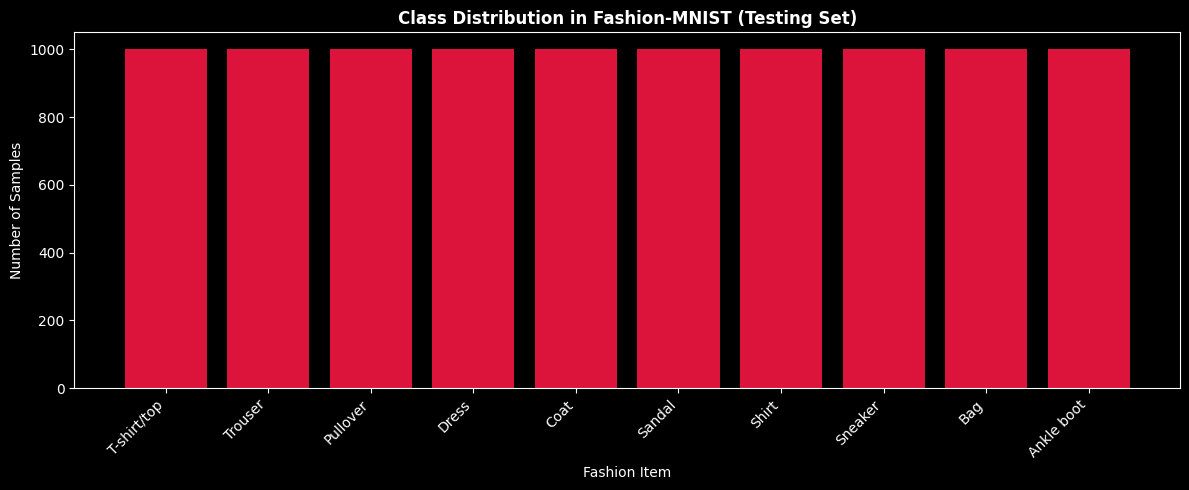

In [15]:
unique, counts = np.unique(y_test, return_counts = True)

plt.figure(figsize = (12, 5))
plt.bar(class_names, counts, color = 'Crimson')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Fashion Item")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Fashion-MNIST (Testing Set)", fontweight = "semibold")
plt.tight_layout()
plt.show()

In [16]:
X_train_with_channels = X_train.reshape(
    X_train.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

X_test_with_channels = X_test.reshape(
    X_test.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

In [17]:
print(f"X_train_with_channels : {X_train_with_channels.shape}")
print(f"X_Test_with_channels : {X_test_with_channels.shape}")

X_train_with_channels : (60000, 28, 28, 1)
X_Test_with_channels : (10000, 28, 28, 1)


In [18]:
X_train_normalized = X_train_with_channels / 255.
X_test_normalized = X_test_with_channels / 255.

In [19]:
X_train_normalized[0][18]

array([[0.01176471],
       [0.79215686],
       [0.89411765],
       [0.87843137],
       [0.86666667],
       [0.82745098],
       [0.82745098],
       [0.83921569],
       [0.80392157],
       [0.80392157],
       [0.80392157],
       [0.8627451 ],
       [0.94117647],
       [0.31372549],
       [0.58823529],
       [1.        ],
       [0.89803922],
       [0.86666667],
       [0.7372549 ],
       [0.60392157],
       [0.74901961],
       [0.82352941],
       [0.8       ],
       [0.81960784],
       [0.87058824],
       [0.89411765],
       [0.88235294],
       [0.        ]])

In [20]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [21]:
print(y_train)
print("-" * 50)
print(y_test)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
--------------------------------------------------
[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [22]:
def create_model(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS):
    FNN_model = Sequential(
        [
            Flatten(input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
            Dense(1000, activation = "relu"),
            Dropout(0.3),
            Dense(500, activation = 'relu'),
            Dropout(0.3),
            Dense(10, activation = "softmax")
        ]
    )

    FNN_model.compile(
        optimizer = 'SGD',
        loss = "categorical_crossentropy",
        metrics = ['accuracy']
    )

    return FNN_model.summary(), FNN_model

In [23]:
_, model = create_model(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)

I0000 00:00:1765868092.566926      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765868092.567610      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,510 (4.92 MB)

 Trainable params: 1,290,510 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

In [25]:
history_FNN = model.fit(
    X_train_normalized,
    y_train,
    validation_split = 0.2,
    epochs = 30,
    batch_size = 32,
    callbacks = [early_stop]
)

Epoch 1/30


I0000 00:00:1765868094.941984     119 service.cc:148] XLA service 0x79d6e4006650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765868094.942478     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765868094.942497     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765868095.088421     119 cuda_dnn.cc:529] Loaded cuDNN version 90300


  72/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2971 - loss: 2.0428

I0000 00:00:1765868096.560425     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6396 - loss: 1.0729 - val_accuracy: 0.8170 - val_loss: 0.5285
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8092 - loss: 0.5568 - val_accuracy: 0.8352 - val_loss: 0.4686
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8308 - loss: 0.4967 - val_accuracy: 0.8453 - val_loss: 0.4330
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8406 - loss: 0.4552 - val_accuracy: 0.8547 - val_loss: 0.4092
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8511 - loss: 0.4285 - val_accuracy: 0.8577 - val_loss: 0.3974
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8560 - loss: 0.4079 - val_accuracy: 0.8626 - val_loss: 0.3828
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8615 - loss: 0.3855 - val_accuracy: 0.8637 - val_loss: 0.3762
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8666 - loss: 0.3812 - val_accurac

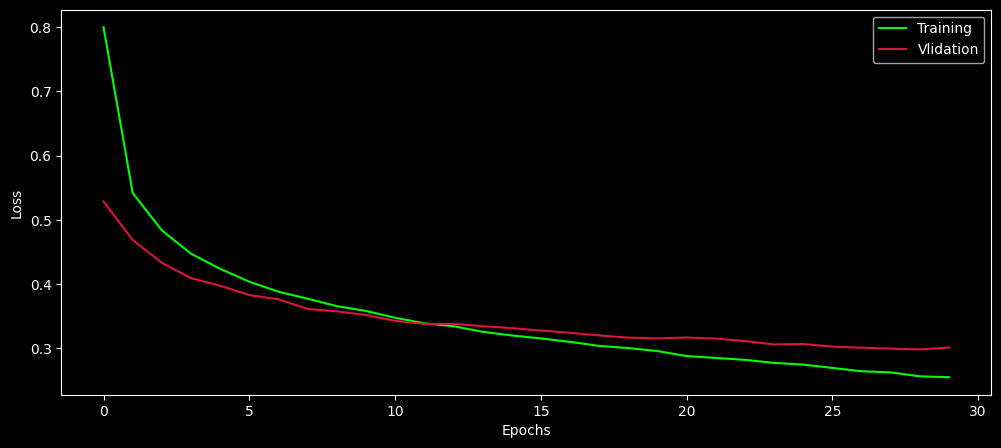

In [26]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['loss'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_loss'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

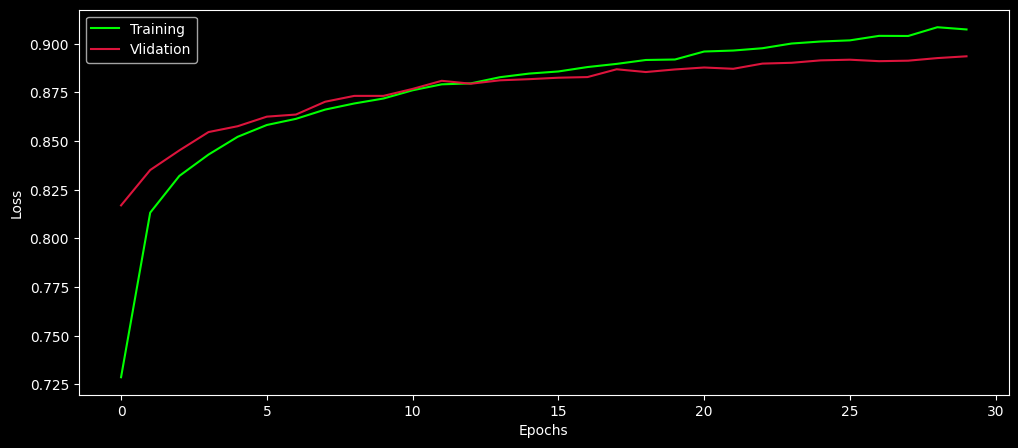

In [27]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['accuracy'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_accuracy'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()